# Hulek-Verrill attractors with JAXVacua

This is a compact working demo for the Hulek-Verrill/AESZ34 attractor points of [arXiv:1912.06146](https://arxiv.org/abs/1912.06146).

The point of this notebook is not to reimplement the special geometry by hand. Instead, we use the paper's attractor data as input to a local custom `period_input`, instantiate `jaxvacua.FluxEFT`, and let JAXVacua compute

$$
e^{-K_{\rm cs}},\qquad W,\qquad DW .
$$

The local period map is only a tangent model around each attractor point. It is sufficient to check the period convention and the F-term equations at the attractor, but it is not yet a global Picard-Fuchs continuation solver.


## Flux vacua and black-hole attractors

The connection used in this notebook is the special Kähler geometry of $H^3(X)$. A four-dimensional BPS black hole in type IIB on a Calabi-Yau threefold carries one integral charge

$$
\Gamma \in H^3(X,\mathbb{Z})
$$

with central charge

$$
Z_\Gamma = e^{K_{\rm cs}/2}\int_X \Gamma \wedge \Omega .
$$

At the horizon, the attractor equations fix the complex-structure moduli by $D_i Z_\Gamma=0$. Equivalently, at the attractor the charge has only $(3,0)+(0,3)$ Hodge components, up to the usual convention-dependent normalisation. A rank-two attractor is the special case in which

$$
L=\left(H^{3,0}\oplus H^{0,3}\right)\cap H^3(X,\mathbb{Z}),
\qquad \operatorname{rank} L=2 .
$$

A type-IIB flux compactification instead chooses two integral three-form fluxes $F_3$, $H_3$ and the axio-dilaton $\tau$, combines them as

$$
G_3=F_3-\tau H_3,
\qquad
W=\int_X G_3\wedge\Omega ,
$$

and solves the flux F-term equations. The equations $D_i W=D_\tau W=0$ are Hodge-alignment conditions on $G_3$: they remove the $(1,2)$ and $(3,0)$ pieces, leaving the imaginary-self-dual components $(2,1)+(0,3)$. If one additionally imposes $W=0$, as in the examples below, the $(0,3)$ part is absent and $G_3$ is of type $(2,1)$.

Thus flux vacua and black-hole attractors are closely parallel, but not identical. A black-hole attractor is specified by one real charge $\Gamma$, while a flux vacuum is specified by the flux doublet $(F_3,H_3)$ together with $\tau$. For the Hulek-Verrill rank-two points this distinction matters: the paper's charge vectors span $L$ and are the correct labels for black-hole attractor flows, whereas the F-term conditions $DW=0$ for flux vacua check uses vectors from the complementary lattice $L_\perp$, encoded in the paper's $D_\phi\Pi$ data, so that $F-\tau H$ lies along the $(2,1)$ direction at the attractor.

Literature pointers:

- Ferrara, Kallosh and Strominger, [N=2 Extremal Black Holes](https://arxiv.org/abs/hep-th/9508072), for the original four-dimensional BPS attractor mechanism.
- Moore, [Arithmetic and Attractors](https://arxiv.org/abs/hep-th/9807087), for attractor varieties and arithmetic aspects of Calabi-Yau attractors.
- Gukov, Vafa and Witten, [CFT's From Calabi-Yau Four-folds](https://arxiv.org/abs/hep-th/9906070), for the flux superpotential used here.
- Denef and Douglas, [Distributions of flux vacua](https://arxiv.org/abs/hep-th/0404116), for flux-vacuum counting and its comparison with attractor-point counting.
- Kallosh, [Flux vacua as supersymmetric attractors](https://arxiv.org/abs/hep-th/0509112), for algebraic attractor equations for type-IIB flux vacua in terms of the flux doublet $(F,H)$.
- Candelas, de la Ossa, Elmi and van Straten, [A One Parameter Family of Calabi-Yau Manifolds with Attractor Points of Rank Two](https://arxiv.org/abs/1912.06146), for the Hulek--Verrill periods, charge lattices and rank-two attractor points used in this notebook.
- Kachru, Nally and Yang [Supersymmetric Flux Compactifications and Calabi-Yau Modularity](https://arxiv.org/pdf/2001.06022) for evidence of the modular properties of supersymmetric flux vacua, and their relationship to the attractor mechanism.
- Candelas, de la Ossa, [Flux Vacua and Modularity for Z2 Symmetric Calabi-Yau Manifolds](https://arxiv.org/pdf/2302.03047) for new families of flux vacua and their modular properties, including the Hulek--Verrill family.


## Imports

In [1]:
from math import sqrt, pi
import os
import warnings

os.environ.setdefault('MPLCONFIGDIR', '/tmp/jaxvacua_mpl_cache')
os.makedirs(os.environ['MPLCONFIGDIR'], exist_ok=True)

import numpy as np
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

from scipy.optimize import root
import matplotlib.pyplot as plt

import jaxvacua

warnings.filterwarnings('ignore')

np.set_printoptions(precision=6, suppress=False)

## Paper input data

The only hard-coded ingredients below are the period values and the attractor tangent data from the paper. All Kähler potential, superpotential, and F-term evaluations below are done by `jaxvacua.FluxEFT`.

For the quotient parameter we use `kappa=1`, corresponding to the `Z/10Z` quotient. Set `kappa=2` for the `Z/5Z` quotient.

In [2]:
# Critical L-values quoted in arXiv:1912.06146.
L14_4_1 = 0.67496319716994177129269568273091339919322842904407
L14_4_2 = 0.91930674266912115653914356907939249680895763199044

L34_4_1_re = 0.61300748403501690756896255581360559790853555213198
L34_4_2_re = 0.72053904959503349611018739597922735350251006854978

v_perp_14 = 0.37369955695472976699767292752499463211766555651682
v_perp_plus = 1.9696894453517505490479716982864516913834531417517
v_perp_minus = 1.0153884942216545916762729868825409864938877880731

sqrt17 = sqrt(17.0)
eps_plus = 4.0 + sqrt17
eps_minus = 4.0 - sqrt17
delta_plus = (3.0 + sqrt17) / 2.0
delta_minus = (3.0 - sqrt17) / 2.0


def paper_period(attractor, kappa=1):
    k = kappa
    if attractor == 'm17':
        return (
            1j * L14_4_1 / (4.0 * pi) * np.array([8*k, -30*k, 0, 5], complex)
            + 7.0 * L14_4_2 / (2.0 * pi**2) * np.array([0, 0, 2, 1], complex)
        )
    if attractor == 'plus':
        return (
            -1j * delta_minus**3 * L34_4_1_re / (2**5 * sqrt17 * pi)
            * np.array([-4*k, 30*k, 30, 5], complex)
            - sqrt17 * eps_minus**2 * delta_plus * L34_4_2_re / (2**3 * pi**2)
            * np.array([4*k, -9*k, 7, 4], complex)
        )
    if attractor == 'minus':
        return (
            1j * eps_plus**3 * delta_minus**3 * L34_4_1_re / (2**5 * sqrt17 * pi)
            * np.array([2*k, 0, 0, -5], complex)
            + sqrt17 * eps_plus * delta_plus * L34_4_2_re / (2**3 * pi**2)
            * np.array([0, 3*k, 1, 0], complex)
        )
    raise ValueError(attractor)


def attractor_phi(attractor):
    if attractor == 'm17':
        return -1.0 / 7.0
    if attractor == 'plus':
        return 33.0 + 8.0 * sqrt17
    if attractor == 'minus':
        return 33.0 - 8.0 * sqrt17
    raise ValueError(attractor)


def paper_K_phi(attractor):
    if attractor == 'm17':
        return -35.0 / 8.0
    if attractor == 'plus':
        return 5.0 / (2**3 * sqrt17) * eps_minus**2 * (2.0 + sqrt17)
    if attractor == 'minus':
        return -5.0 / (2**3 * sqrt17) * eps_plus**2 * (2.0 - sqrt17)
    raise ValueError(attractor)

## Charges and fluxes

The black-hole charge lattice `L` from the paper can be embedded as a pure RR flux `[Q | 0]`, but that is not the natural supersymmetric IIB flux choice.

For `DW=0`, we use the orthogonal lattice `L_perp`, equivalently the paper's `D_phi Pi` expressions. The following function returns integer `F`, `H`, the associated `tau`, and the JAXVacua flux vector `[F | H]`.

In [ ]:
def black_hole_charge_generators(attractor, kappa=1):
    k = int(kappa)
    if attractor == 'm17':
        return np.array([4*k, -15*k, -5, 0]), np.array([0, 0, 2, 1])
    if attractor == 'plus':
        return np.array([4*k, -9*k, 7, 4]), np.array([4*k, -30*k, -30, -5])
    if attractor == 'minus':
        return np.array([-2*k, 0, 0, 5]), np.array([0, 3*k, 1, 0])
    raise ValueError(attractor)


def flux_from_Lperp(attractor, kappa=1):
    k = int(kappa)
    if attractor == 'm17':
        F = np.array([-5*k, 10*k, -5, -3])
        H = np.array([-7*k, 14*k, -10, -5])
        tau = 0.5 + 1j * v_perp_14
    elif attractor == 'plus':
        # DPi is proportional to a - tau^{-1} b; multiply by -tau.
        a = np.array([9*k, -16*k, 20, 9])
        b = np.array([15*k, -36*k, 15, 11])
        F = b
        H = a
        tau = 1j * v_perp_plus
    elif attractor == 'minus':
        # DPi is proportional to a + tau b.
        a = np.array([0, -2*k, 5, 0])
        b = np.array([3*k, 0, 0, 1])
        F = a
        H = -b
        tau = 1j * v_perp_minus
    else:
        raise ValueError(attractor)

    fluxes = np.concatenate([F, H])
    
    return F, H, tau, fluxes


for name in ['m17', 'plus', 'minus']:
    e1, e2 = black_hole_charge_generators(name)
    F, H, tau, fluxes = flux_from_Lperp(name)
    print(name)
    print('  black-hole L generators:', e1, e2)
    print('  F =', F)
    print('  H =', H)
    print('  tau =', tau)
    print('  jaxvacua fluxes =', fluxes)

m17
  black-hole L generators: [  4 -15  -5   0] [0 0 2 1]
  F = [-5 10 -5 -3]
  H = [ -7  14 -10  -5]
  tau = (0.5+0.3736995569547298j)
  jaxvacua fluxes = [ -5  10  -5  -3  -7  14 -10  -5]
plus
  black-hole L generators: [ 4 -9  7  4] [  4 -30 -30  -5]
  F = [ 15 -36  15  11]
  H = [  9 -16  20   9]
  tau = 1.9696894453517506j
  jaxvacua fluxes = [ 15 -36  15  11   9 -16  20   9]
minus
  black-hole L generators: [-2  0  0  5] [0 3 1 0]
  F = [ 0 -2  5  0]
  H = [-3  0  0 -1]
  tau = 1.0153884942216547j
  jaxvacua fluxes = [ 0 -2  5  0 -3  0  0 -1]


## Local JAXVacua model: detailed $\phi=-1/7$ example

The attractor point discussed first in the paper is

$$
\phi_*=-\frac{1}{7} .
$$

This section shows the construction step by step:

1. build the attractor period vector $\Pi_*$ from the paper;
2. translate the $L_\perp$ vectors into JAXVacua fluxes $[F\mid H]$;
3. construct a local period map whose covariant derivative satisfies $D_\phi\Pi_*=F-\tau H$;
4. instantiate `jaxvacua.FluxEFT` and evaluate $A$, $W$, and $DW$;
5. recover the minimum by solving `model.DW_x = 0` from a nearby starting point.

The local period map is only a tangent model around the attractor. It is enough for the F-term check at $\phi_*$, but it is not a replacement for a global Picard-Fuchs continuation routine.


In [4]:
def make_local_period_input(phi_star, Pi_star, dPi_star):
    """Local holomorphic period map Pi(phi) = Pi_* + (phi - phi_*) dPi_*."""
    phi_star = jnp.asarray(phi_star, dtype=jnp.complex128)
    Pi_star = jnp.asarray(Pi_star, dtype=jnp.complex128)
    dPi_star = jnp.asarray(dPi_star, dtype=jnp.complex128)

    def period_input(X, conj=False):
        # JAXVacua calls custom period_input with homogeneous coordinates X=(X^0, X^1).
        # We use X^1 as the local family coordinate phi and keep X^0 as the projective gauge.
        phi = X[1]
        if conj:
            return jnp.conj(Pi_star) + (phi - jnp.conj(phi_star)) * jnp.conj(dPi_star)
        return Pi_star + (phi - phi_star) * dPi_star

    return period_input

### Step 1: construct the period vector

For $\kappa=1$, the paper gives

$$
\Pi\!\left(-\frac{1}{7}\right)
=\frac{iL_4(1)}{4\pi}\,(8,-30,0,5)
+\frac{7L_4(2)}{2\pi^2}\,(0,0,2,1) .
$$

The entries are already ordered as JAXVacua expects: $(F_0,F_1,X^0,X^1)$.


In [5]:
kappa = 1
phi_star = attractor_phi('m17')
Pi_star = paper_period('m17', kappa=kappa)

print('phi_* =', phi_star)
print('Pi_*  =', Pi_star)
print('special coordinate X^1/X^0 =', Pi_star[3] / Pi_star[2])

phi_* = -0.14285714285714285
Pi_*  = [0.        +0.42969492j 0.        -1.61135594j 0.65201673+0.j
 0.32600837+0.26855932j]
special coordinate X^1/X^0 = (0.5+0.41189023269472697j)


### Step 2: translate the fluxes

The black-hole charges in the paper span the attractor lattice $L$. For a supersymmetric IIB flux check we instead use the orthogonal $L_\perp$ data from the paper's $D\Pi$ expression:

$$
F=(-5,10,-5,-3),\qquad
H=(-7,14,-10,-5),\qquad
\tau=\frac{1}{2}+i v_\perp .
$$

These are placed into JAXVacua as $\mathrm{fluxes}=[F\mid H]$.


In [6]:
F_star, H_star, tau_star, fluxes_star_np = flux_from_Lperp('m17', kappa=kappa)
G_star = F_star - tau_star * H_star

print('F      =', F_star)
print('H      =', H_star)
print('tau    =', tau_star)
print('[F|H]  =', fluxes_star_np)
print('G=F-tau H =', G_star)

F      = [-5 10 -5 -3]
H      = [ -7  14 -10  -5]
tau    = (0.5+0.3736995569547298j)
[F|H]  = [ -5  10  -5  -3  -7  14 -10  -5]
G=F-tau H = [-1.5+2.6158969j   3. -5.2317938j   0. +3.73699557j -0.5+1.86849778j]


### Step 3: adapt the local period map to JAXVacua

JAXVacua differentiates the user-supplied period map. The paper gives the covariant derivative direction. If

$$
D_\phi\Pi=\partial_\phi\Pi+K_\phi\Pi,
$$

then we choose the local derivative

$$
\partial_\phi\Pi_*=(F-\tau H)-K_\phi\Pi_* .
$$

With this convention, JAXVacua sees exactly $D_\phi\Pi_*=F-\tau H$ at the attractor.


In [7]:
K_phi_star = paper_K_phi('m17')
dPi_star = G_star - K_phi_star * Pi_star

period_input_m17 = make_local_period_input(phi_star, Pi_star, dPi_star)
model_m17 = jaxvacua.FluxEFT(h12=1, limit=None, period_input=period_input_m17)

z_star = jnp.array([phi_star + 0.0j], dtype=jnp.complex128)
zc_star = jnp.conj(z_star)
fluxes_star = jnp.asarray(fluxes_star_np, dtype=jnp.float64)

print('K_phi =', K_phi_star)
print('partial_phi Pi_* =', dPi_star)

K_phi = -4.375
partial_phi Pi_* = [-1.5       +4.49581216j  3.       -12.28147603j  2.8525732 +3.73699557j
  0.9262866 +3.04344482j]


### Step 4: evaluate the attractor with JAXVacua

The quantities in the next cell are computed by JAXVacua methods, not by manual symplectic products in the notebook.

In [8]:
A_star = model_m17.A(z_star, zc_star)
W_star = model_m17.W(z_star, tau_star, fluxes_star)
DW_star = model_m17.DW(z_star, zc_star, tau_star, jnp.conj(tau_star), fluxes_star)

print('e^-K_cs =', complex(A_star))
print('W       =', complex(W_star), 'abs =', float(jnp.abs(W_star)))
print('DW      =', np.asarray(DW_star))
print('max|DW| =', float(jnp.max(jnp.abs(DW_star))))

e^-K_cs = (0.4902944814347493-0j)
W       = (4.440892098500626e-16+0j) abs = 4.440892098500626e-16
DW      = [ 1.60982339e-15+4.02455846e-16j -1.48544868e-16+5.94179471e-16j]
max|DW| = 1.659367964464312e-15


### Step 5: recover the minimum from `DW_x`

`DW_x` is JAXVacua's real F-term interface. For one complex-structure modulus the real vector is

$$
x=(\operatorname{Re}\phi,\operatorname{Im}\phi,\operatorname{Re}\tau,\operatorname{Im}\tau) .
$$

Starting near the attractor, `scipy.optimize.root` converges back to the paper's value.


In [21]:
x_exact = np.array([phi_star, 0.0, tau_star.real, tau_star.imag], dtype=float)
x0 = x_exact + np.array([0.02, 0.01, 0.03, -0.02])+np.random.uniform(0, 1, size=4)*10

res = root(model_m17.DW_x, x0, args=(fluxes_star,), jac=model_m17.dDW_x, method='hybr', tol=1e-10)

print('success:', res.success)
print('initial x0:', x0)
print('solution:', res.x)
print('target:  ', x_exact)
print('residual norm:', np.linalg.norm(model_m17.DW_x(res.x, fluxes_star)))

success: True
initial x0: [9.19604542 0.33567476 7.98180572 4.36114562]
solution: [-1.42857143e-01  1.27234717e-14  5.00000000e-01  3.73699557e-01]
target:   [-0.14285714  0.          0.5         0.37369956]
residual norm: 3.932231286305951e-13


## Figure-2-style local flow schematic

Figure 2 of the paper shows attractor-flow curves in the `phi` plane for black-hole charge generators leading to rank-two attractor points. The plot below reinstates that earlier notebook view: the endpoints and charge labels use the paper data, while the curves are schematic paths drawn on the cut plane.

The labels refer to the black-hole charge generators spanning the paper's lattice `L`. They are not the same objects as the `L_perp` fluxes used above for the IIB `DW=0` check. To compute the actual flow trajectories we would need a global Hulek--Verrill period evaluator and the attractor-flow ODE; the local JAXVacua model is only a tangent model at the endpoint.

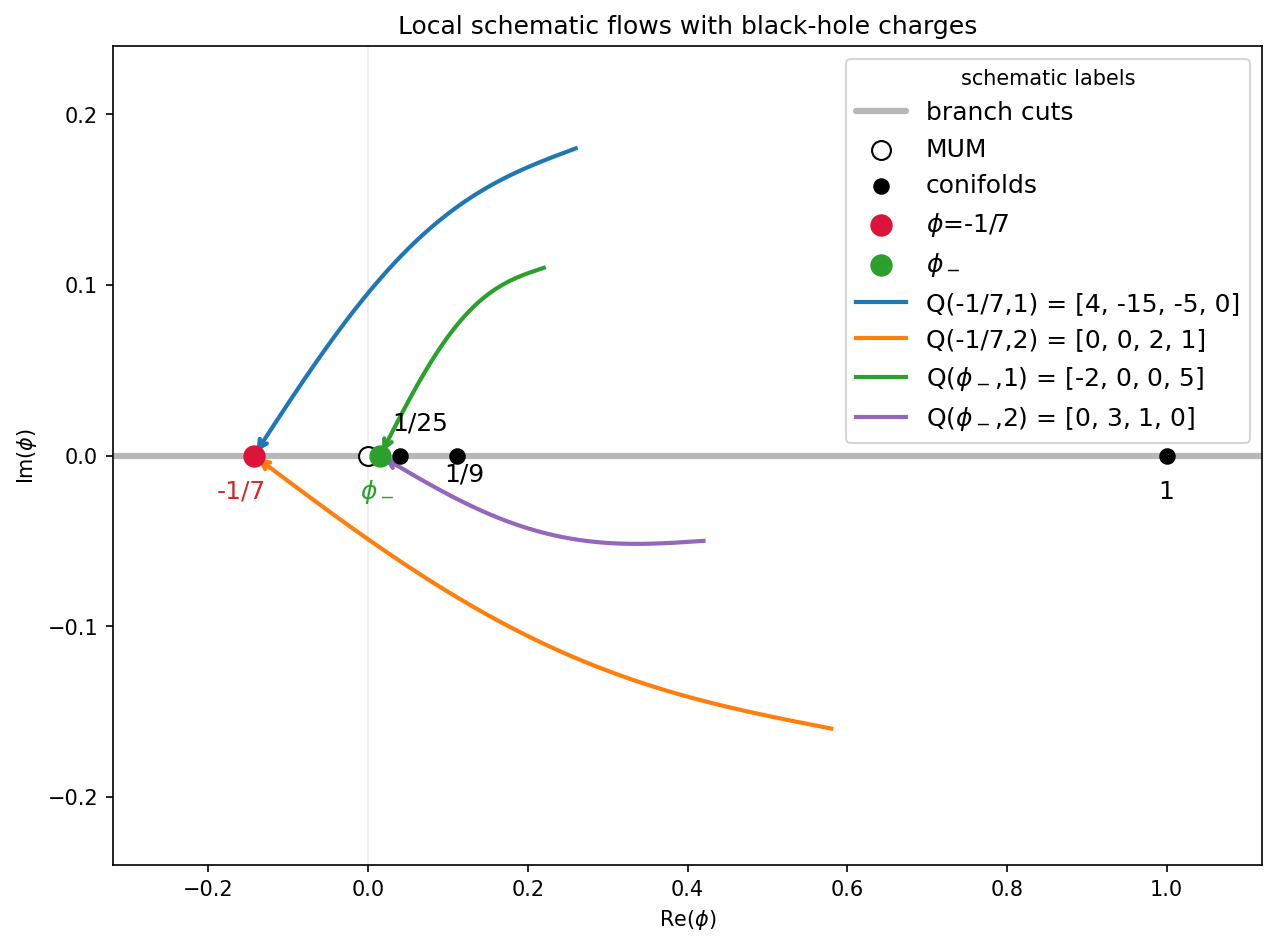

In [34]:
def _format_charge(q):
    return '[' + ', '.join(str(int(x)) for x in q) + ']'


def _schematic_flow(start, end, bend=0.0, n=180):
    t = np.linspace(0.0, 1.0, n)
    start = complex(start)
    end = complex(end)
    curve = (1.0 - t) * start + t * end
    curve += 1j * bend * np.sin(np.pi * t)
    return curve


def plot_phi_plane_schematic():
    phi_m17 = attractor_phi('m17')
    phi_minus = attractor_phi('minus')
    conifolds = np.array([1/25, 1/9, 1.0])
    m17_e1, m17_e2 = black_hole_charge_generators('m17')
    minus_e1, minus_e2 = black_hole_charge_generators('minus')

    flows = [
        (0.26 + 0.18j, phi_m17, 0.035, 'tab:blue', 'Q(-1/7,1) = ' + _format_charge(m17_e1)),
        (0.58 - 0.16j, phi_m17, -0.030, 'tab:orange', 'Q(-1/7,2) = ' + _format_charge(m17_e2)),
        (0.22 + 0.11j, phi_minus, 0.025, 'tab:green', 'Q($\phi_-$,1) = ' + _format_charge(minus_e1)),
        (0.42 - 0.05j, phi_minus, -0.020, 'tab:purple', 'Q($\phi_-$,2) = ' + _format_charge(minus_e2)),
    ]

    fig, ax = plt.subplots(figsize=(8.4, 6.2), constrained_layout=True, dpi=150)
    ax.plot([-0.32, 0.0], [0.0, 0.0], color='0.72', lw=3, solid_capstyle='round', label='branch cuts')
    ax.plot([1/25, 1.12], [0.0, 0.0], color='0.72', lw=3, solid_capstyle='round')
    ax.scatter([0.0], [0.0], s=82, facecolors='white', edgecolors='black', zorder=5, label='MUM')
    ax.scatter(conifolds, np.zeros_like(conifolds), s=48, color='black', zorder=5, label='conifolds')
    ax.scatter([phi_m17], [0.0], s=95, color='crimson', zorder=6, label='$\phi$=-1/7')
    ax.scatter([phi_minus], [0.0], s=95, color='tab:green', zorder=6, label='$\phi_-$')

    for start, end, bend, color, label in flows:
        curve = _schematic_flow(start, end, bend=bend)
        ax.plot(curve.real, curve.imag, color=color, lw=2.0, label=label)
        ax.annotate(
            '',
            xy=(curve.real[-1], curve.imag[-1]),
            xytext=(curve.real[-7], curve.imag[-7]),
            arrowprops=dict(arrowstyle='->', color=color, lw=2.0),
        )

    ax.annotate('-1/7', xy=(phi_m17, 0.0), xytext=(-0.19, -0.025), color="tab:red",fontsize=12)
    ax.annotate(r'$\phi_-$', xy=(phi_minus, 0.0), xytext=(-.01, -0.025), color="tab:green", fontsize=12)
    ax.annotate('1/25', xy=(1/25, 0.0), xytext=(0.03, 0.015), fontsize=12)
    ax.annotate('1/9', xy=(1/9, 0.0), xytext=(0.095, -0.015), fontsize=12)
    ax.annotate('1', xy=(1.0, 0.0), xytext=(0.99, -0.025), fontsize=12)

    ax.axhline(0.0, color='0.9', lw=0.8, zorder=0)
    ax.axvline(0.0, color='0.92', lw=0.8, zorder=0)
    ax.set_xlim(-0.32, 1.12)
    ax.set_ylim(-0.24, 0.24)
    ax.set_xlabel(r'Re$(\phi)$')
    ax.set_ylabel(r'Im$(\phi)$')
    ax.set_title('Local schematic flows with black-hole charges')
    ax.legend(loc='upper right', fontsize=12, title='schematic labels')
    return fig, ax


plot_phi_plane_schematic();


## Compact check for all three attractors

The helper below applies the same construction to `phi=-1/7` and to the two quadratic attractors `phi=33 +/- 8 sqrt(17)`.

In [26]:
def build_attractor_model(attractor, kappa=1):
    phi = attractor_phi(attractor)
    Pi = paper_period(attractor, kappa=kappa)
    K_phi = paper_K_phi(attractor)
    F, H, tau, fluxes = flux_from_Lperp(attractor, kappa=kappa)

    G = F - tau * H
    dPi = G - K_phi * Pi
    period_input = make_local_period_input(phi, Pi, dPi)

    model = jaxvacua.FluxEFT(h12=1, limit=None, period_input=period_input)
    return model, phi, tau, jnp.asarray(fluxes, dtype=jnp.float64)


for name in ['m17', 'plus', 'minus']:
    model, phi, tau, fluxes = build_attractor_model(name, kappa=1)
    z = jnp.array([phi + 0.0j], dtype=jnp.complex128)
    zc = jnp.conj(z)

    A = model.A(z, zc)
    W = model.W(z, tau, fluxes)
    DW = model.DW(z, zc, tau, jnp.conj(tau), fluxes)

    print(name)
    print('  phi =', phi)
    print('  e^-K_cs =', complex(A))
    print('  W       =', complex(W), 'abs =', float(jnp.abs(W)))
    print('  max|DW| =', float(jnp.max(jnp.abs(DW))))

m17
  phi = -0.14285714285714285
  e^-K_cs = (0.4902944814347493-0j)
  W       = (4.440892098500626e-16+0j) abs = 4.440892098500626e-16
  max|DW| = 1.659367964464312e-15
plus
  phi = 65.98484500494129
  e^-K_cs = (1.8083381368695707e-05-0j)
  W       = (-5.551115123125783e-17+0j) abs = 5.551115123125783e-17
  max|DW| = 1.8198773652309366e-13
minus
  phi = 0.015154995058715315
  e^-K_cs = (5.195319300400597-0j)
  W       = 0j abs = 0.0
  max|DW| = 7.105427357601002e-15


## What remains for a global model

This notebook now reproduces the attractor F-term checks with JAXVacua's internal `FluxEFT` machinery and demonstrates root finding for `phi=-1/7`.

The missing production component is still a genuine period evaluator for the Hulek--Verrill family. That would let us replace the local tangent period input by a global or patchwise map and then compute actual attractor-flow curves like Figure 2, rather than the schematic above.